In [4]:
import pandas as pd
from pyterrier_t5 import MonoT5ReRanker
import pyterrier as pt
if not pt.started():
    pt.init()

import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_27589/1620703191.py:4: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


In [7]:
results = pd.read_csv("./all_random_score_distribution.csv")
results

,docno,text,qid,query,sensitivity,label,score,rank
0,88159880,Pancreatic transplantation for diabetes mellit...,53176,can pancreatic transplantation cause diabetes ...,1,1,-0.547887,0
1,88068618,"Correlations, descent measures: drift with mig...",12068,correlations descent measures,0,1,-0.145469,0
2,88162359,Dexamethasone in bronchopulmonary dysplasia [l...,25222,is dexamethasone used for bronchopulmonary dys...,0,1,-0.226504,0
3,89143789,Role for carbohydrate structures in TGF-beta 1...,91783,what is the role of carbohydrate structures in...,0,1,-0.064530,0
4,90074736,Procedures for evaluating innovatory proposals...,203145,what is the objective of the innovatory proposal,0,1,-0.365215,0
...,...,...,...,...,...,...,...,...
668263,87319666,The Odyssey of a brochure on AIDS [news] The e...,119879,is nifedipine harmful,0,0,-13.012868,1
668264,89256357,Left heart opacification with peripheral venou...,259178,hyaluronate in patients with osteoarthritis,0,0,-13.931581,1
668265,89204279,Tolerance and the thymus. A 62-year-old man ar...,131932,what is the final step in aldosterone biosynth...,0,0,-12.345542,1
668266,88297620,Unions eager to exploit labor board rule. In t...,146867,are colonic staple anastomoses a radiological ...,0,0,-14.123190,1


/tmp/ipykernel_27589/113080933.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results, x='label_sensitivity', y='score', palette=palette)
/tmp/ipykernel_27589/113080933.py:23: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(data=results, x='label_sensitivity', y='score', palette=palette)


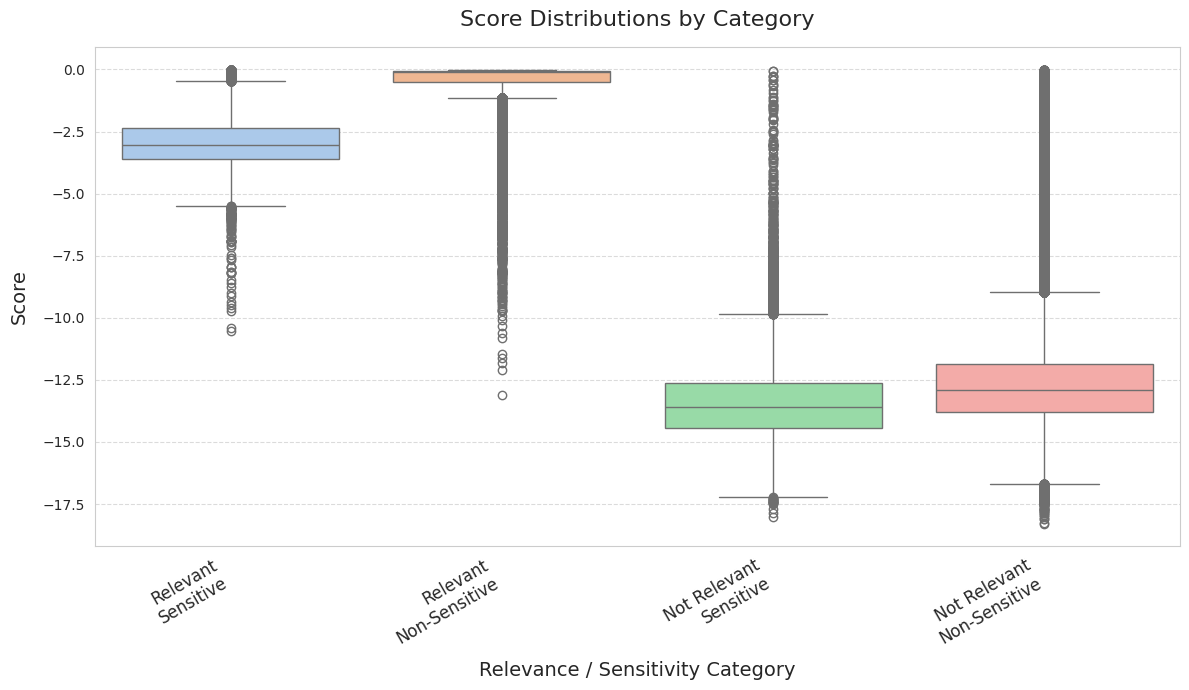

In [3]:
results['label_sensitivity'] = results['label'].map({1: "Relevant", 0: "Not Relevant"}) + "\n" + results['sensitivity'].map({1: "Sensitive", 0: "Non-Sensitive"})

# # Set plot style
# plt.figure(figsize=(10, 6))
# sns.boxplot(data=results, x='label_sensitivity', y='score')

# # Label the axes
# plt.xlabel("Label & Sensitivity Combination")
# plt.ylabel("Score")
# plt.title("Box Plots of Score Distributions by Label and Sensitivity")

# # Show the plot
# plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
# plt.show()

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Define a better color palette
palette = sns.color_palette("pastel")

# Create the boxplot
sns.boxplot(data=results, x='label_sensitivity', y='score', palette=palette)

# Label the axes with larger fonts
plt.xlabel("Relevance / Sensitivity Category", fontsize=14, labelpad=10)
plt.ylabel("Score", fontsize=14, labelpad=10)

# Set title with a larger font
plt.title("Score Distributions by Category", fontsize=16, pad=15)

# Rotate x-axis labels for better readability and adjust spacing
plt.xticks(rotation=30, ha="right", fontsize=12)

# Reduce gridline intensity for a cleaner look
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
# Show the plot
# plt.savefig("./plots/monot5_score_distributions.png", dpi = 1080)
plt.show()